In [ ]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.3 MB/s eta 0:00:00


In [ ]:
import warnings
import logging

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress specific warnings from hmmlearn
warnings.filterwarnings("ignore", category=UserWarning, module='hmmlearn')
warnings.filterwarnings("ignore", category=RuntimeWarning, module='hmmlearn')
warnings.filterwarnings("ignore", category=FutureWarning, module='hmmlearn')

# Disable logging for hmmlearn
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

##Gaussian HMM on Ionosphere and Breast Cancer datasets



=== Dataset: Ionosphere ===

Grid Search Results (sorted by CV accuracy):
 n_components covariance_type  n_iter  cv_accuracy
            2            full     500     0.837607
            2            full     100     0.837607
            2            diag     500     0.729345
            2            diag     100     0.729345
            3            diag     100     0.729345
            3            diag     500     0.729345
            4            diag     500     0.720798
            4            diag     100     0.720798
            3            full     500     0.603989
            3            full     100     0.603989
            4            full     100     0.555556
            4            full     500     0.555556

Best Parameters: {'n_components': 2, 'covariance_type': 'full', 'n_iter': 100}

Performance Metrics for Different Splits:
 Train %  Test %  Accuracy  Precision   Recall  F1 Score  ROC AUC
      80      20  0.760563   0.765501 0.777409  0.758841 0.777409
      7

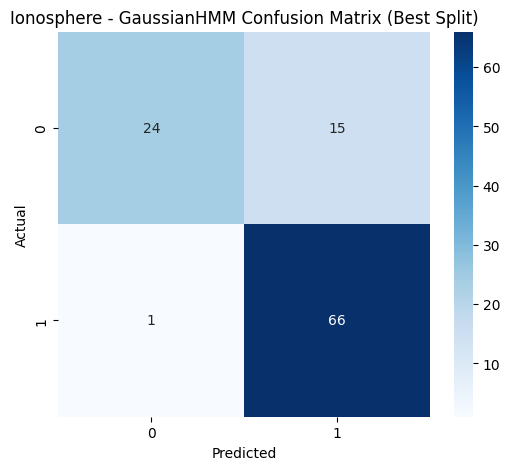

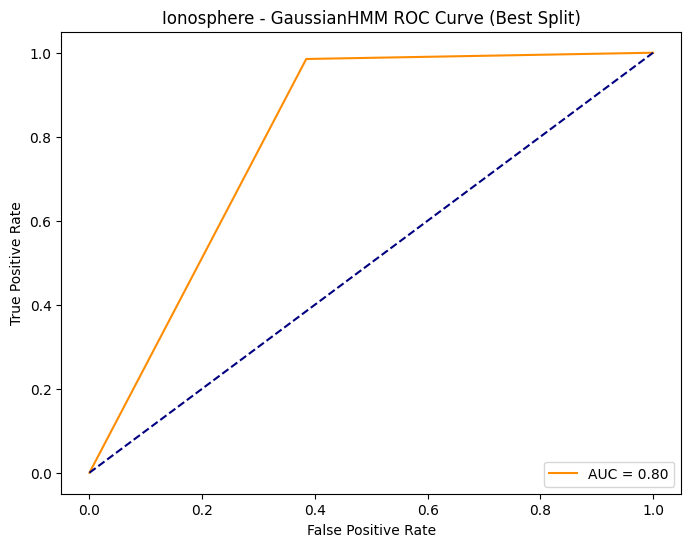


=== Dataset: Breast Cancer ===

Grid Search Results (sorted by CV accuracy):
 n_components covariance_type  n_iter  cv_accuracy
            2            diag     100     0.912086
            2            diag     500     0.912086
            2            full     100     0.896241
            2            full     500     0.896241
            3            full     500     0.745039
            3            full     100     0.745039
            4            full     100     0.702859
            4            full     500     0.702859
            3            diag     100     0.685547
            3            diag     500     0.685547
            4            diag     500     0.564198
            4            diag     100     0.564198

Best Parameters: {'n_components': 2, 'covariance_type': 'diag', 'n_iter': 100}

Performance Metrics for Different Splits:
 Train %  Test %  Accuracy  Precision   Recall  F1 Score  ROC AUC
      80      20  0.938596   0.933117 0.936947  0.934947 0.936947
    

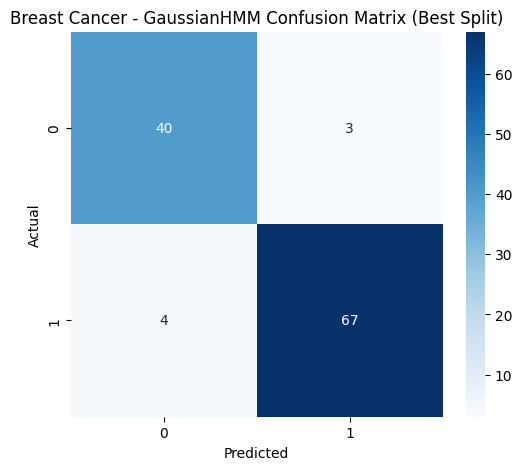

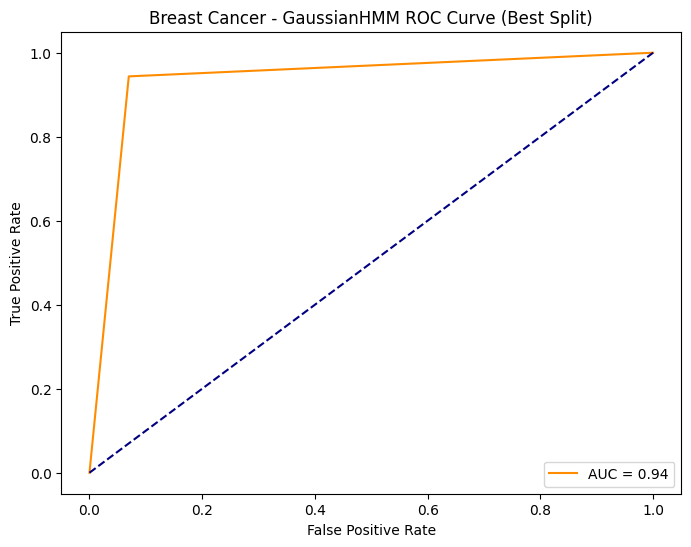

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.datasets import load_breast_cancer
from scipy.optimize import linear_sum_assignment
import warnings

warnings.filterwarnings("ignore")

# Load datasets
def load_ionosphere():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
    df = pd.read_csv(url, header=None)
    X = df.iloc[:, :-1].values
    y = np.where(df.iloc[:, -1] == 'g', 1, 0)
    return X, y

def load_breast_cancer_dataset():
    data = load_breast_cancer()
    return data.data, data.target

# Helper functions
def best_map(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for col, row in zip(col_ind, row_ind)}
    return np.vectorize(mapping.get)(y_pred)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_mapped = best_map(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred_mapped)
    prec = precision_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    return acc, prec, rec, f1

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

def plot_roc_curve(y_test, y_pred, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange')
    plt.plot([0,1],[0,1], linestyle='--', color='navy')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

# Grid Search for GaussianHMM
def grid_search_gaussian(X, y, param_grid, cv=3):
    results = []
    best_score, best_params = 0, None
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    for n_components in param_grid['n_components']:
        for cov_type in param_grid['covariance_type']:
            for n_iter in param_grid['n_iter']:
                scores = []
                for train_idx, test_idx in skf.split(X, y):
                    X_train, X_test = X[train_idx], X[test_idx]
                    y_train, y_test = y[train_idx], y[test_idx]
                    model = GaussianHMM(n_components=n_components,
                                        covariance_type=cov_type,
                                        n_iter=n_iter,
                                        random_state=42)
                    try:
                        model.fit(X_train)
                        y_pred_mapped = best_map(y_test, model.predict(X_test))
                        scores.append(np.mean(y_pred_mapped == y_test))
                    except:
                        continue
                avg_score = np.mean(scores) if scores else 0
                results.append({
                    'n_components': n_components,
                    'covariance_type': cov_type,
                    'n_iter': n_iter,
                    'cv_accuracy': avg_score
                })
                if avg_score > best_score:
                    best_score = avg_score
                    best_params = {'n_components': n_components,
                                   'covariance_type': cov_type,
                                   'n_iter': n_iter}
    results_df = pd.DataFrame(results)
    return best_params, results_df

# Running GaussianHMM on multiple splits
def run_gaussian_hmm_splits(X, y, dataset_name, test_sizes=[0.2,0.3,0.4]):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\n=== Dataset: {dataset_name} ===")

    param_grid = {'n_components':[2,3,4], 'covariance_type':['diag','full'], 'n_iter':[100,500]}
    best_params, results_df = grid_search_gaussian(X_scaled, y, param_grid)

    print("\nGrid Search Results (sorted by CV accuracy):")
    print(results_df.sort_values(by='cv_accuracy', ascending=False).to_string(index=False))
    print("\nBest Parameters:", best_params)

    metrics_summary = []
    for test_size in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
        model = GaussianHMM(n_components=best_params['n_components'],
                            covariance_type=best_params['covariance_type'],
                            n_iter=best_params['n_iter'],
                            random_state=42)
        model.fit(X_train)
        acc, prec, rec, f1 = evaluate_model(model, X_test, y_test)

        y_pred = model.predict(X_test)
        y_pred_mapped = best_map(y_test, y_pred)
        try:
            roc_auc = roc_auc_score(y_test, y_pred_mapped)
        except:
            roc_auc = np.nan

        metrics_summary.append({
            'Train %': int((1-test_size)*100),
            'Test %': int(test_size*100),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'model': model
        })

    metrics_df = pd.DataFrame(metrics_summary)
    print("\nPerformance Metrics for Different Splits:")
    print(metrics_df[['Train %','Test %','Accuracy','Precision','Recall','F1 Score','ROC AUC']].to_string(index=False))

    # Best split
    best_idx = metrics_df['Accuracy'].idxmax()
    best_split = metrics_df.iloc[best_idx]
    print(f"\nBest Split: Train {best_split['Train %']}% - Test {best_split['Test %']}% with Accuracy {best_split['Accuracy']:.4f} and ROC AUC {best_split['ROC AUC']:.4f}")

    # Confusion Matrix and ROC Curve for best split
    y_pred = best_split['model'].predict(best_split['X_test'])
    y_pred_mapped = best_map(best_split['y_test'], y_pred)
    cm = confusion_matrix(best_split['y_test'], y_pred_mapped)
    plot_confusion_matrix(cm, title=f"{dataset_name} - GaussianHMM Confusion Matrix (Best Split)")
    plot_roc_curve(best_split['y_test'], y_pred_mapped, title=f"{dataset_name} - GaussianHMM ROC Curve (Best Split)")

# Main Execution
if __name__ == "__main__":
    datasets = [("Ionosphere", load_ionosphere()), ("Breast Cancer", load_breast_cancer_dataset())]
    for name, (X,y) in datasets:
        run_gaussian_hmm_splits(X, y, name)

##Multinomial HMM on Ionosphere and Breast Cancer datasets


=== Dataset: Ionosphere ===

Grid Search Results (sorted by CV accuracy):
 n_components  n_iter  cv_accuracy
            2     100     0.544160
            2     500     0.544160
            3     100     0.532764
            3     500     0.532764
            4     100     0.532764
            4     500     0.532764

Best Parameters: {'n_components': 2, 'n_iter': 100}

Performance Metrics for Different Splits:
 Train %  Test %  Accuracy  Precision   Recall  F1 Score  ROC AUC
      80      20  0.521127   0.492308 0.492525  0.492003 0.492525
      70      30  0.537736   0.488971 0.489667  0.488125 0.489667
      60      40  0.503546   0.601634 0.576008  0.492284 0.576008

Best Split: Train 70% - Test 30% with Accuracy 0.5377 and ROC AUC 0.4897


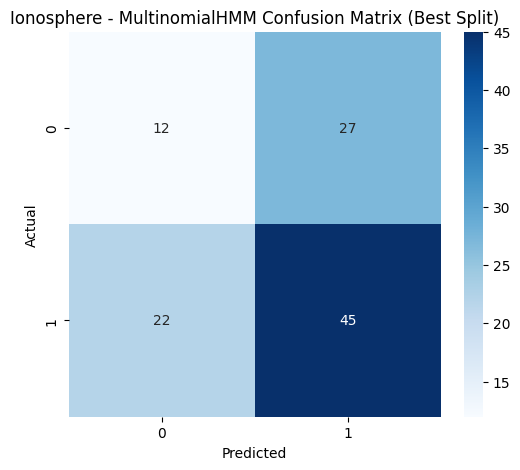

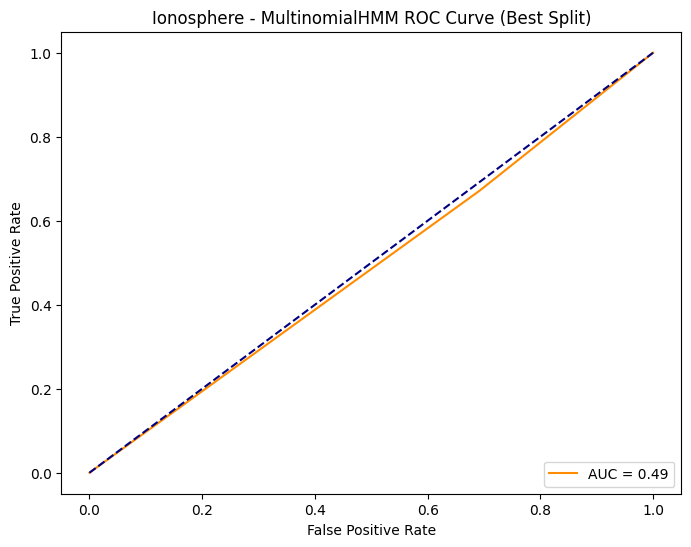


=== Dataset: Breast Cancer ===

Grid Search Results (sorted by CV accuracy):
 n_components  n_iter  cv_accuracy
            2     100     0.780358
            2     500     0.780358
            3     100     0.613376
            3     500     0.613376
            4     100     0.502692
            4     500     0.502692

Best Parameters: {'n_components': 2, 'n_iter': 100}

Performance Metrics for Different Splits:
 Train %  Test %  Accuracy  Precision   Recall  F1 Score  ROC AUC
      80      20  0.798246   0.792593 0.810514  0.793657 0.810514
      70      30  0.812865   0.798364 0.805556  0.801451 0.805556
      60      40  0.807018   0.787698 0.793919  0.790511 0.793919

Best Split: Train 70% - Test 30% with Accuracy 0.8129 and ROC AUC 0.8056


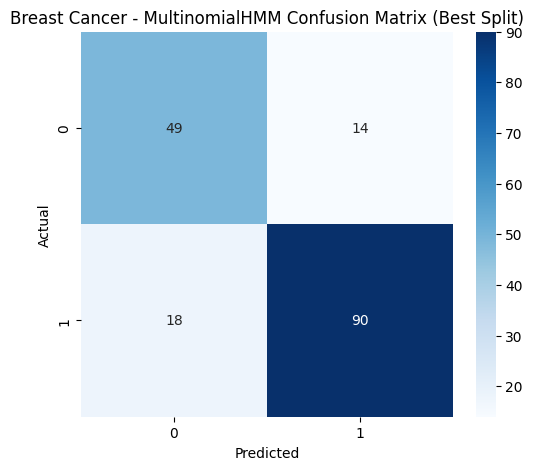

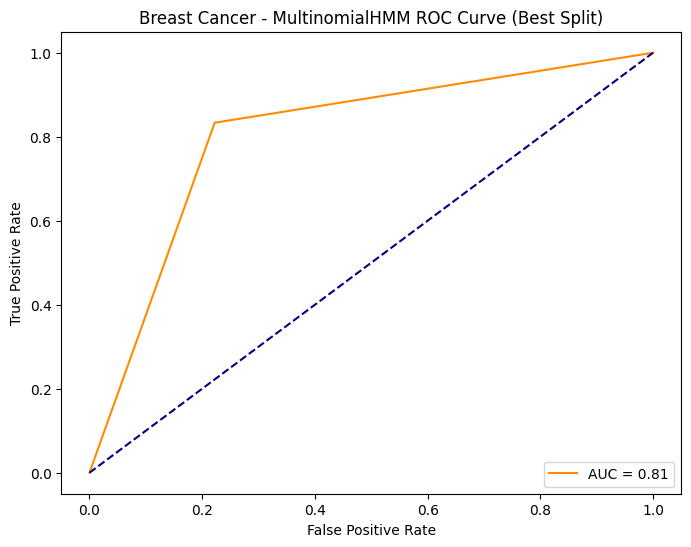

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from hmmlearn.hmm import MultinomialHMM
from sklearn.datasets import load_breast_cancer
from scipy.optimize import linear_sum_assignment
import warnings

warnings.filterwarnings("ignore")


# Load datasets

def load_ionosphere():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data"
    df = pd.read_csv(url, header=None)
    X = df.iloc[:, :-1].values
    y = np.where(df.iloc[:, -1] == 'g', 1, 0)
    return X, y

def load_breast_cancer_dataset():
    data = load_breast_cancer()
    return data.data, data.target


# Helper functions

def best_map(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for col, row in zip(col_ind, row_ind)}
    return np.vectorize(mapping.get)(y_pred)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_mapped = best_map(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred_mapped)
    prec = precision_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred_mapped, average='macro', zero_division=0)
    return acc, prec, rec, f1

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

def plot_roc_curve(y_test, y_pred, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange')
    plt.plot([0,1],[0,1], linestyle='--', color='navy')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()


# Grid Search for MultinomialHMM

def grid_search_multinomial(X, y, param_grid, cv=3):
    results = []
    best_score, best_params = 0, None
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    for n_components in param_grid['n_components']:
        for n_iter in param_grid['n_iter']:
            scores = []
            for train_idx, test_idx in skf.split(X, y):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                model = MultinomialHMM(n_components=n_components, n_iter=n_iter, random_state=42)
                try:
                    model.fit(X_train)
                    y_pred_mapped = best_map(y_test, model.predict(X_test))
                    scores.append(np.mean(y_pred_mapped == y_test))
                except:
                    continue
            avg_score = np.mean(scores) if scores else 0
            results.append({
                'n_components': n_components,
                'n_iter': n_iter,
                'cv_accuracy': avg_score
            })
            if avg_score > best_score:
                best_score = avg_score
                best_params = {'n_components': n_components, 'n_iter': n_iter}

    results_df = pd.DataFrame(results)
    return best_params, results_df


# Run MultinomialHMM with multiple splits

def run_multinomial_hmm_splits(X, y, dataset_name, n_bins=10, test_sizes=[0.2,0.3,0.4]):
    # Discretize features for MultinomialHMM
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    X_disc = discretizer.fit_transform(X_scaled).astype(int)

    print(f"\n=== Dataset: {dataset_name} ===")
    param_grid = {'n_components':[2,3,4], 'n_iter':[100,500]}
    best_params, results_df = grid_search_multinomial(X_disc, y, param_grid)

    print("\nGrid Search Results (sorted by CV accuracy):")
    print(results_df.sort_values(by='cv_accuracy', ascending=False).to_string(index=False))
    print("\nBest Parameters:", best_params)

    metrics_summary = []
    for test_size in test_sizes:
        X_train, X_test, y_train, y_test = train_test_split(X_disc, y, test_size=test_size, random_state=42)
        model = MultinomialHMM(n_components=best_params['n_components'],
                               n_iter=best_params['n_iter'],
                               random_state=42)
        model.fit(X_train)
        acc, prec, rec, f1 = evaluate_model(model, X_test, y_test)

        y_pred = model.predict(X_test)
        y_pred_mapped = best_map(y_test, y_pred)
        try:
            roc_auc = roc_auc_score(y_test, y_pred_mapped)
        except:
            roc_auc = np.nan

        metrics_summary.append({
            'Train %': int((1-test_size)*100),
            'Test %': int(test_size*100),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'model': model
        })

    metrics_df = pd.DataFrame(metrics_summary)
    print("\nPerformance Metrics for Different Splits:")
    print(metrics_df[['Train %','Test %','Accuracy','Precision','Recall','F1 Score','ROC AUC']].to_string(index=False))

    # Best split
    best_idx = metrics_df['Accuracy'].idxmax()
    best_split = metrics_df.iloc[best_idx]
    print(f"\nBest Split: Train {best_split['Train %']}% - Test {best_split['Test %']}% with Accuracy {best_split['Accuracy']:.4f} and ROC AUC {best_split['ROC AUC']:.4f}")

    # Confusion Matrix and ROC Curve
    y_pred = best_split['model'].predict(best_split['X_test'])
    y_pred_mapped = best_map(best_split['y_test'], y_pred)
    cm = confusion_matrix(best_split['y_test'], y_pred_mapped)
    plot_confusion_matrix(cm, title=f"{dataset_name} - MultinomialHMM Confusion Matrix (Best Split)")
    plot_roc_curve(best_split['y_test'], y_pred_mapped, title=f"{dataset_name} - MultinomialHMM ROC Curve (Best Split)")

# =============================
# Main Execution
# =============================
if __name__ == "__main__":
    datasets = [("Ionosphere", load_ionosphere()), ("Breast Cancer", load_breast_cancer_dataset())]
    for name, (X,y) in datasets:
        run_multinomial_hmm_splits(X, y, name, n_bins=10)

##CNN on CIFAR-10


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.2693 - loss: 1.9603 - val_accuracy: 0.4897 - val_loss: 1.3893
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4753 - loss: 1.4440 - val_accuracy: 0.5507 - val_loss: 1.2229
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.5480 - loss: 1.2511 - val_accuracy: 0.6132 - val_loss: 1.0767
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5896 - loss: 1.1581 - val_accuracy: 0.6411 - val_loss: 0.9899
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6133 - loss: 1.0879 - val_accuracy: 0.6576 - val_loss: 0.9501
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6379 - loss: 1.0235 - val_accuracy: 0.6505 - val_loss: 0.9730
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.6456 - loss: 0.9930 - val_accuracy: 0.6901 - val_loss: 0.8706
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.6612 - loss: 0.9581 - val_accurac

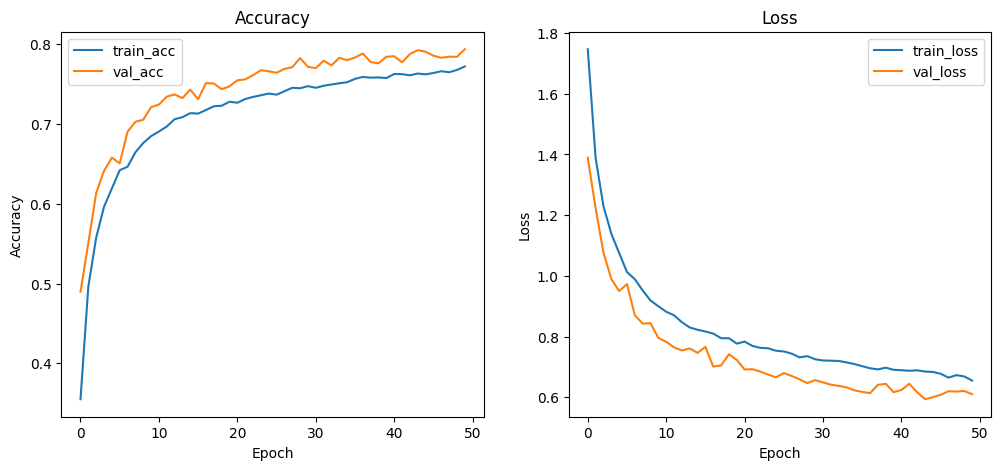

In [ ]:

# CIFAR-10 CNN Full Implementation


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


# 1. Load and preprocess CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize images
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# 2. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of training for validation
)
datagen.fit(X_train)


# 3. Build CNN Model
model = models.Sequential()

# Conv Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Conv Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Fully Connected Layers
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))


# 4. Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# 5. Train Model
batch_size = 64
epochs = 50

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size, subset='training'),
    validation_data=datagen.flow(X_train, y_train, batch_size=batch_size, subset='validation'),
    epochs=epochs
)

# 6. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


# 7. Plot Training History

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##CNN on MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7908 - loss: 0.6192 - val_accuracy: 0.9872 - val_loss: 0.0436
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9715 - loss: 0.0990 - val_accuracy: 0.9895 - val_loss: 0.0343
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9784 - loss: 0.0717 - val_accuracy: 0.9918 - val_loss: 0.0280
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9826 - loss: 0.0582 - val_accuracy: 0.9925 - val_loss: 0.0280
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9841 - loss: 0.0521 - val_accuracy: 0.9930 - val_loss: 0.0241
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9879 - loss: 0.0393 - val_accuracy: 0.9932 - val_loss: 0.0268
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9889 - loss: 0.0366 - val_accuracy: 0.9928 - val_loss: 0.0249
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

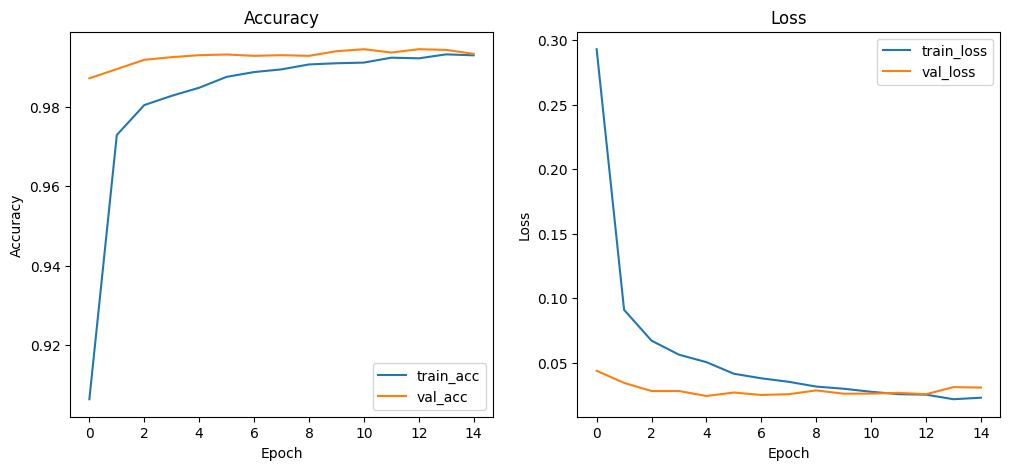

In [ ]:
# MNIST CNN Full Implementation

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load and preprocess MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape to (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Build CNN Model
model = models.Sequential()

# Conv Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Conv Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Fully Connected Layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# 3. Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train Model
history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1)

# 5. Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# 6. Plot Training History
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##VGG-16 from scratch (weights=None) on CIFAR-10

In [ ]:

# Optimized VGG-16 from Scratch: CIFAR-10


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau


# 1. Load and preprocess CIFAR-10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
input_shape = (32,32,3)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)


# 3. Build Optimized VGG-16 Model

def build_vgg16_optimized(input_shape, num_classes):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 4
    model.add(layers.Conv2D(512, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(512, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Fully Connected
    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = build_vgg16_optimized(input_shape, num_classes)


# 4. Compile Model

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# 5. Learning Rate Scheduler

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                 patience=5,
                                 factor=0.5,
                                 min_lr=1e-5,
                                 verbose=1)


# 6. Train Model

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[lr_reduction]
)


# 7. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy on CIFAR-10: {test_acc:.4f}")

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_125 (Conv2D)             │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_126 (Conv2D)             │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_130 (Conv2D)             │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 10,274,122 (39.19 MB)

 Trainable params: 10,268,746 (39.17 MB)

 Non-trainable params: 5,376 (21.00 KB)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 74ms/step - accuracy: 0.1569 - loss: 2.4154 - val_accuracy: 0.3177 - val_loss: 1.7182 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.3242 - loss: 1.7296 - val_accuracy: 0.3046 - val_loss: 2.3852 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.4202 - loss: 1.5274 - val_accuracy: 0.4167 - val_loss: 1.6109 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.5287 - loss: 1.3248 - val_accuracy: 0.6190 - val_loss: 1.1299 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.6033 - loss: 1.1596 - val_accuracy: 0.5941 - val_loss: 1.2467 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.6553 - loss: 1.0334 - val_accuracy: 0.5936 - val_loss: 1.1262 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.6965 - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


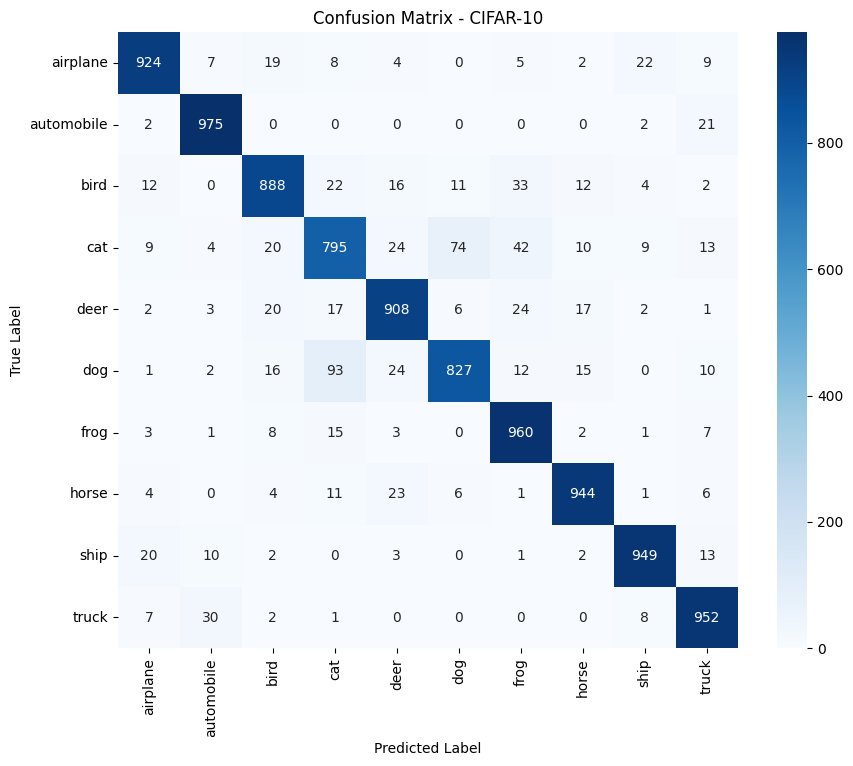

Classification Report:
              precision    recall  f1-score   support

    airplane     0.9390    0.9240    0.9315      1000
  automobile     0.9448    0.9750    0.9596      1000
        bird     0.9070    0.8880    0.8974      1000
         cat     0.8264    0.7950    0.8104      1000
        deer     0.9035    0.9080    0.9057      1000
         dog     0.8950    0.8270    0.8597      1000
        frog     0.8905    0.9600    0.9240      1000
       horse     0.9402    0.9440    0.9421      1000
        ship     0.9509    0.9490    0.9499      1000
       truck     0.9207    0.9520    0.9361      1000

    accuracy                         0.9122     10000
   macro avg     0.9118    0.9122    0.9116     10000
weighted avg     0.9118    0.9122    0.9116     10000



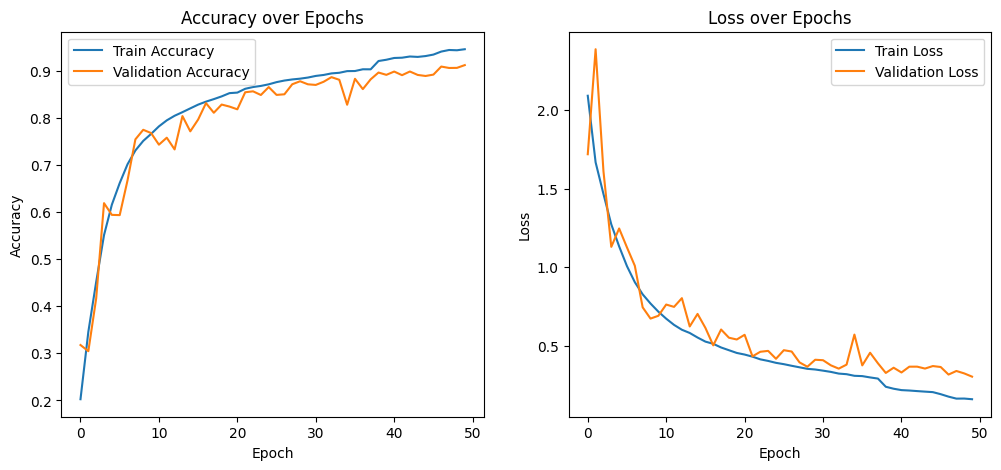

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np


# 8. Evaluate & Visualize Results with Labels

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CIFAR-10')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Classification Report

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))


# Training & Validation Accuracy/Loss Curves

plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##VGG-16 with ImageNet weights on CIFAR-10

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,982,474 (57.15 MB)

 Trainable params: 267,786 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.2507 - loss: 2.0828 - val_accuracy: 0.4719 - val_loss: 1.5531
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.4315 - loss: 1.6219 - val_accuracy: 0.5076 - val_loss: 1.4282
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.4734 - loss: 1.5079 - val_accuracy: 0.5241 - val_loss: 1.3703
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.4959 - loss: 1.4567 - val_accuracy: 0.5354 - val_loss: 1.3324
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.5049 - loss: 1.4195 - val_accuracy: 0.5423 - val_loss: 1.3071
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.5193 - loss: 1.3756 - val_accuracy: 0.5543 - val_loss: 1.2773
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.5273 - loss: 1.3548 - val_accuracy: 0.5578 - val_loss: 1.2661
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.5309 - loss: 1.3457 - 

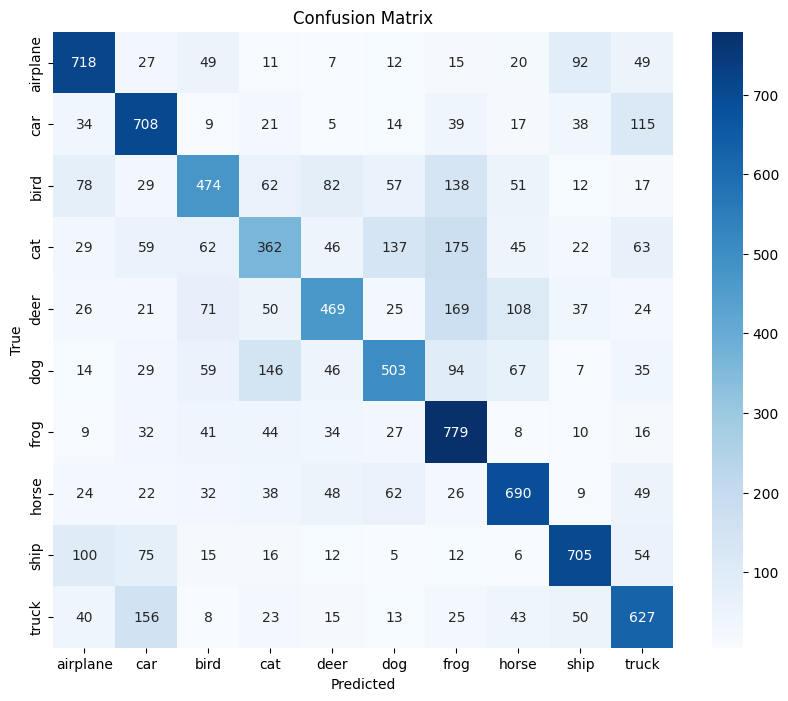

Classification Report:

              precision    recall  f1-score   support

    airplane       0.67      0.72      0.69      1000
         car       0.61      0.71      0.66      1000
        bird       0.58      0.47      0.52      1000
         cat       0.47      0.36      0.41      1000
        deer       0.61      0.47      0.53      1000
         dog       0.59      0.50      0.54      1000
        frog       0.53      0.78      0.63      1000
       horse       0.65      0.69      0.67      1000
        ship       0.72      0.70      0.71      1000
       truck       0.60      0.63      0.61      1000

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



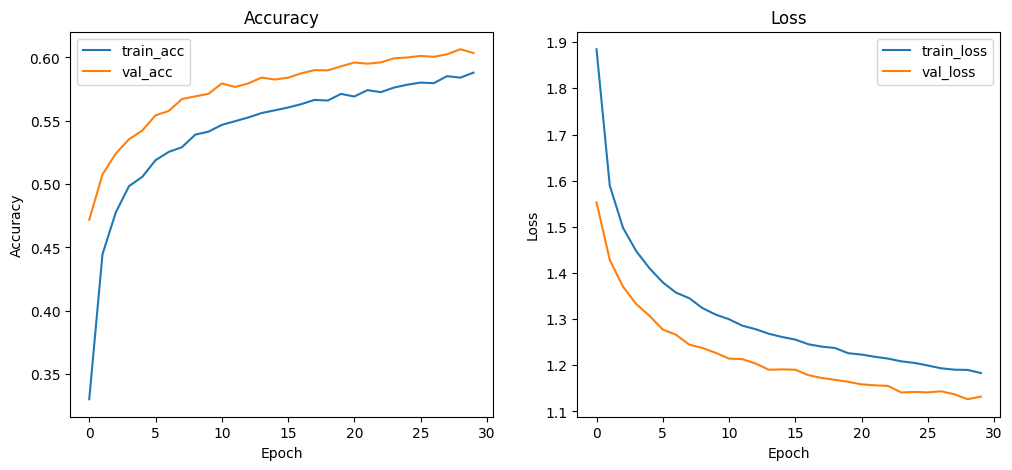

In [ ]:

# VGG-16 Transfer Learning on CIFAR-10


import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load CIFAR-10 Dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
num_classes = 10
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

# Normalize images
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


# 3. Load Pretrained VGG-16 (ImageNet) and Build Model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# Freeze the base model
base_model.trainable = False

# Add custom classification layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# 4. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test_cat)
)


# 5. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()


# 6. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# 7. Classification Report

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# 8. Training & Validation Accuracy/Loss Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##VGG-16 from scratch (weights=None) on MNIST


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_142 (Conv2D)             │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_143 (Conv2D)             │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_144 (Conv2D)             │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_145 (Conv2D)             │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_146 (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_147 (Conv2D)             │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_148 (Conv2D)             │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,158,250 (4.42 MB)

 Trainable params: 1,158,250 (4.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6617 - loss: 0.9288 - val_accuracy: 0.9817 - val_loss: 0.0571
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9732 - loss: 0.0957 - val_accuracy: 0.9890 - val_loss: 0.0324
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9811 - loss: 0.0688 - val_accuracy: 0.9870 - val_loss: 0.0415
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9843 - loss: 0.0550 - val_accuracy: 0.9938 - val_loss: 0.0276
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9871 - loss: 0.0486 - val_accuracy: 0.9913 - val_loss: 0.0310
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9875 - loss: 0.0453 - val_accuracy: 0.9938 - val_loss: 0.0248
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9875 - loss: 0.0450 - val_accuracy: 0.9925 - val_loss: 0.0242
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9905 - loss: 0.0348 - val_accuracy:

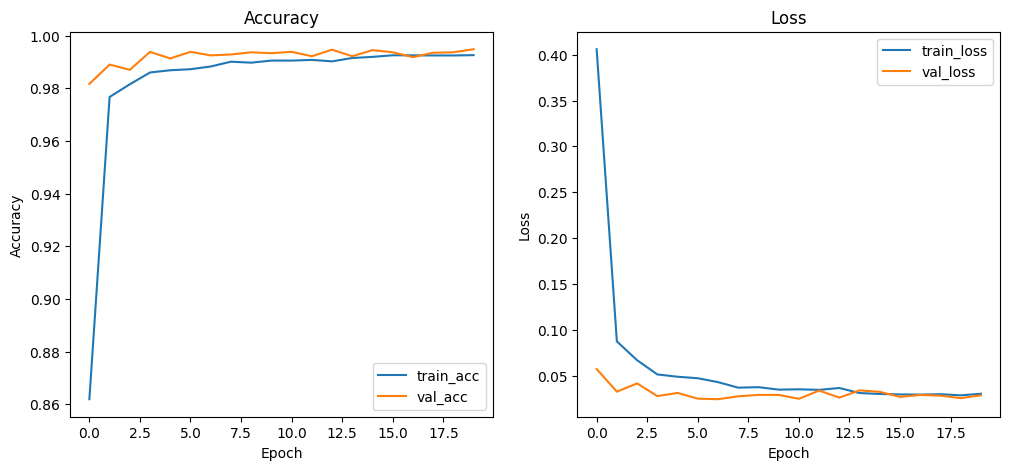

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


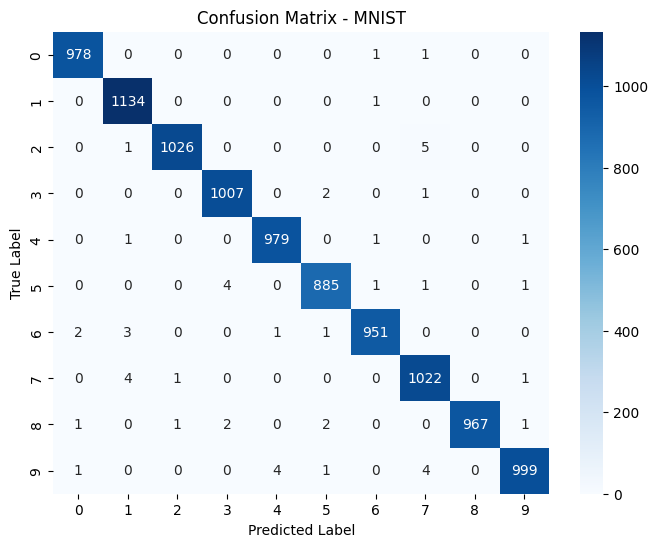

Classification Report:
              precision    recall  f1-score   support

           0     0.9959    0.9980    0.9969       980
           1     0.9921    0.9991    0.9956      1135
           2     0.9981    0.9942    0.9961      1032
           3     0.9941    0.9970    0.9956      1010
           4     0.9949    0.9969    0.9959       982
           5     0.9933    0.9922    0.9927       892
           6     0.9958    0.9927    0.9942       958
           7     0.9884    0.9942    0.9913      1028
           8     1.0000    0.9928    0.9964       974
           9     0.9960    0.9901    0.9930      1009

    accuracy                         0.9948     10000
   macro avg     0.9949    0.9947    0.9948     10000
weighted avg     0.9948    0.9948    0.9948     10000



In [ ]:

# VGG-16 From Scratch for MNIST


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


# 1. Load and preprocess MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape to (samples, height, width, channels) and normalize
X_train = X_train.reshape(-1,28,28,1).astype('float32') / 255.0
X_test = X_test.reshape(-1,28,28,1).astype('float32') / 255.0

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
input_shape = (28,28,1)


# 2. Build VGG-16 Model

def build_vgg16_mnist(input_shape, num_classes):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = build_vgg16_mnist(input_shape, num_classes)


# 3. Compile Model

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# 4. Train Model

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.1)


# 5. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy on MNIST: {test_acc:.4f}")


# 6. Plot Training & Validation Accuracy/Loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 7. Confusion Matrix & Classification Report

import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict class probabilities
y_pred = model.predict(X_test)
# Convert predictions and true labels to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Define class names (digits 0–9)
class_names = [str(i) for i in range(10)]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MNIST')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))


##VGG-16 with ImageNet weights on MNIST

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 77ms/step - accuracy: 0.4386 - loss: 1.7234 - val_accuracy: 0.8588 - val_loss: 0.6446
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - accuracy: 0.7950 - loss: 0.7030 - val_accuracy: 0.9045 - val_loss: 0.4063
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 72ms/step - accuracy: 0.8557 - loss: 0.4954 - val_accuracy: 0.9223 - val_loss: 0.3120
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.8811 - loss: 0.4103 - val_accuracy: 0.9334 - val_loss: 0.2598
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.8973 - loss: 0.3468 - val_accuracy: 0.9399 - val_loss: 0.2258
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.9083 - loss: 0.3108 - val_accuracy: 0.9459 - val_loss: 0.2004
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.9169 - loss: 0.2793 - val_accuracy: 0.9492 - val_loss: 0.1833
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.9215 - loss: 0.2624 - 

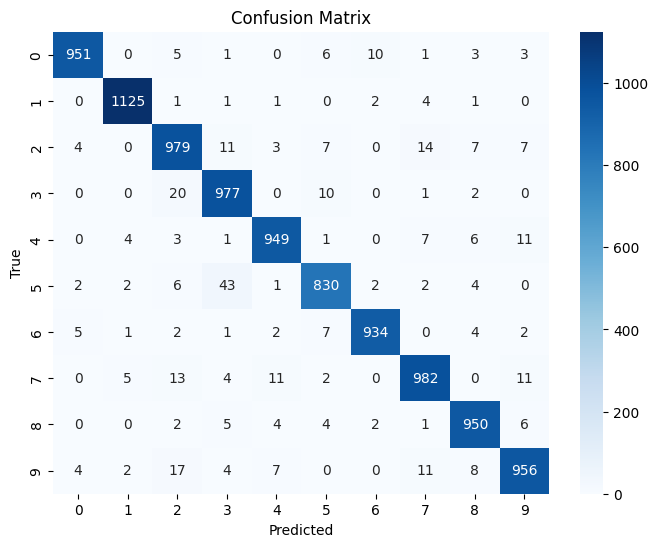

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.93      0.95      0.94      1032
           3       0.93      0.97      0.95      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.93      0.94       892
           6       0.98      0.97      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.96      0.98      0.97       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



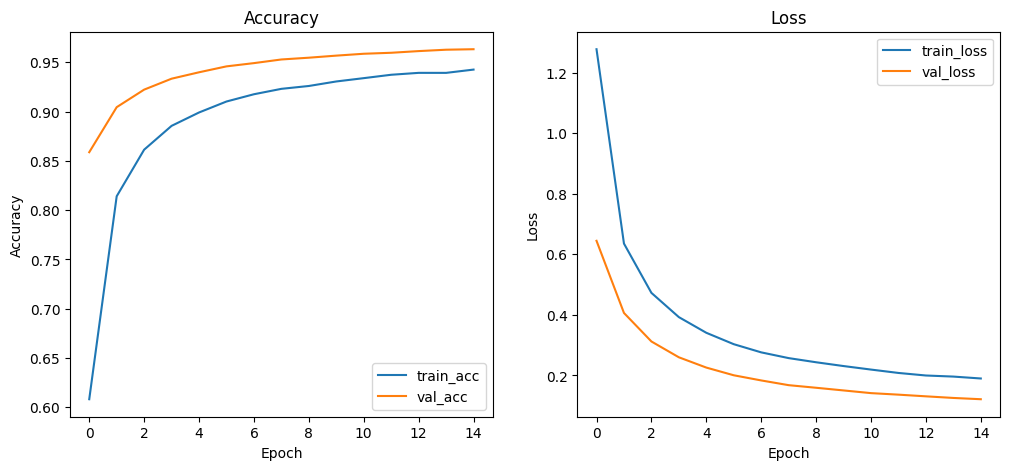

In [ ]:

# VGG-16 Transfer Learning on MNIST


import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# 1. Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_classes = 10
class_names = [str(i) for i in range(10)]

# Normalize and convert to 3 channels
X_train = np.stack([X_train]*3, axis=-1).astype('float32') / 255.0
X_test = np.stack([X_test]*3, axis=-1).astype('float32') / 255.0

# Resize to 48x48 (VGG16 performs better with larger images)
X_train = tf.image.resize(X_train, [48,48])
X_test = tf.image.resize(X_test, [48,48])

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False  # digits should not flip
)
datagen.fit(X_train)


# 3. Load Pretrained VGG-16 (ImageNet) and Build Model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(48,48,3))
base_model.trainable = False  # Freeze base

# Add custom classifier
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# 4. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=15,
    validation_data=(X_test, y_test_cat)
)


# 5. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy on MNIST: {test_acc:.4f}")


# 6. Predictions, Confusion Matrix, Classification Report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# 7. Training & Validation Accuracy/Loss Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##RNN (LSTM) on CIFAR-10

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,754 (655.29 KB)

 Trainable params: 167,754 (655.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 26ms/step - accuracy: 0.2844 - loss: 1.9169 - val_accuracy: 0.4935 - val_loss: 1.3822
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4818 - loss: 1.4289 - val_accuracy: 0.5730 - val_loss: 1.1756
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.5513 - loss: 1.2595 - val_accuracy: 0.6263 - val_loss: 1.0515
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5947 - loss: 1.1510 - val_accuracy: 0.6478 - val_loss: 0.9847
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6237 - loss: 1.0732 - val_accuracy: 0.6761 - val_loss: 0.9111
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6408 - loss: 1.0250 - val_accuracy: 0.6714 - val_loss: 0.9328
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6589 - loss: 0.9795 - val_accuracy: 0.7007 - val_loss: 0.8582
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.6696 - loss: 0.95

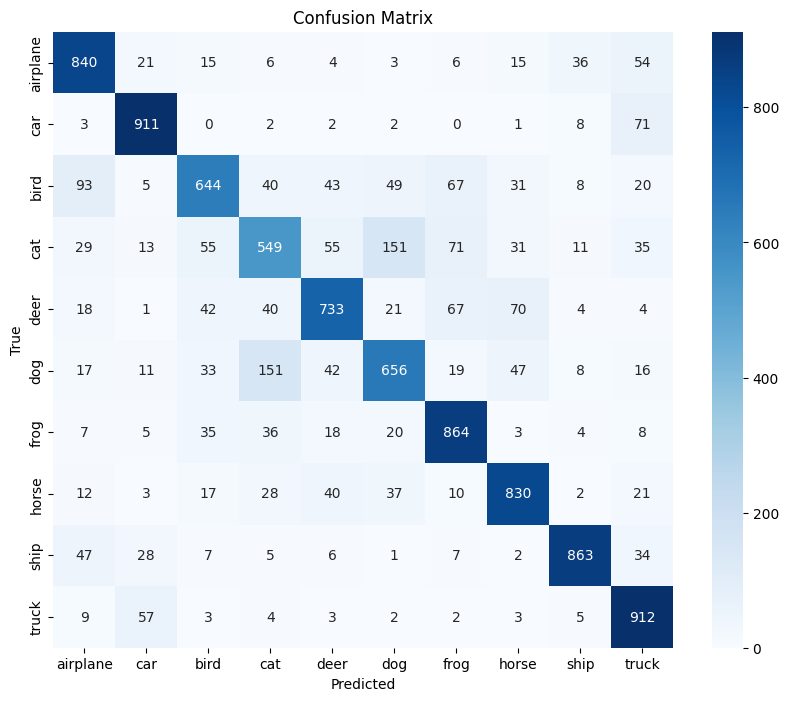

Classification Report:

              precision    recall  f1-score   support

    airplane       0.78      0.84      0.81      1000
         car       0.86      0.91      0.89      1000
        bird       0.76      0.64      0.70      1000
         cat       0.64      0.55      0.59      1000
        deer       0.77      0.73      0.75      1000
         dog       0.70      0.66      0.68      1000
        frog       0.78      0.86      0.82      1000
       horse       0.80      0.83      0.82      1000
        ship       0.91      0.86      0.89      1000
       truck       0.78      0.91      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



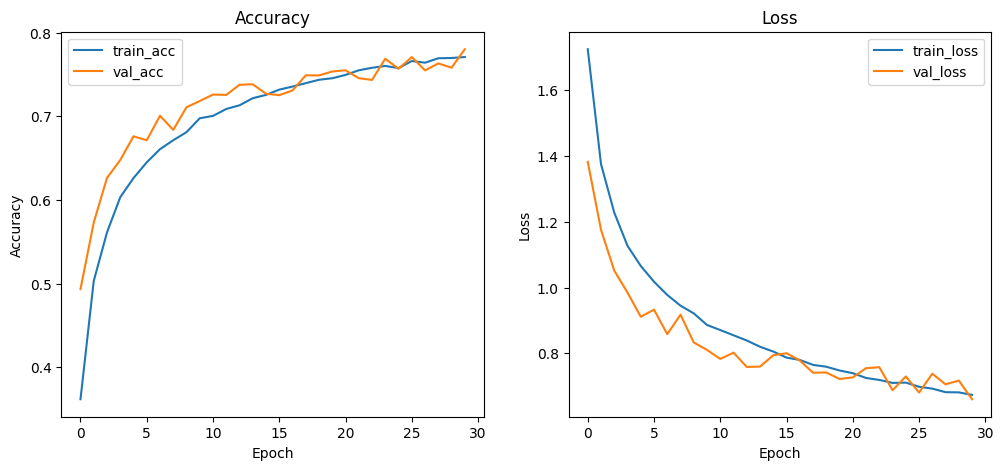

In [ ]:

# CNN-LSTM on CIFAR-10 (Optimized)


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load CIFAR-10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
num_classes = 10
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


# 3. Build CNN-LSTM Model

inputs = layers.Input(shape=(32,32,3))
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)

# Reshape for LSTM: (batch, time_steps, features)
x = layers.Reshape((8, 8*64))(x)  # sequence length = 8, features = 512
x = layers.LSTM(64)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


# 4. Train Model

history = model.fit(datagen.flow(X_train, y_train_cat, batch_size=32),
                    epochs=30,
                    validation_data=(X_test, y_test_cat))


# 5. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")


# 6. Predictions, Confusion Matrix & Classification Report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# 7. Training & Validation Accuracy/Loss Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##RNN (LSTM) on MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 128)        │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,602 (525.79 KB)

 Trainable params: 134,602 (525.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6101 - loss: 1.1518 - val_accuracy: 0.9442 - val_loss: 0.1828
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9418 - loss: 0.2132 - val_accuracy: 0.9617 - val_loss: 0.1263
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9646 - loss: 0.1329 - val_accuracy: 0.9753 - val_loss: 0.0842
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9704 - loss: 0.1055 - val_accuracy: 0.9761 - val_loss: 0.0898
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9791 - loss: 0.0781 - val_accuracy: 0.9804 - val_loss: 0.0673
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9830 - loss: 0.0627 - val_accuracy: 0.9832 - val_loss: 0.0582
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9847 - loss: 0.0569 - val_accuracy: 0.9845 - val_loss: 0.0523
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9861 - loss: 0.0510 - val_accur

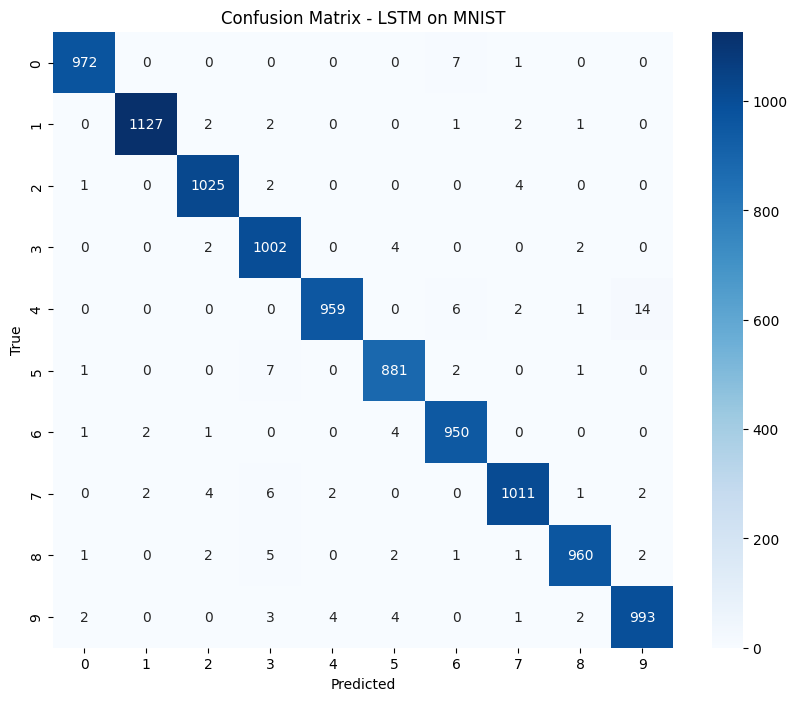

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



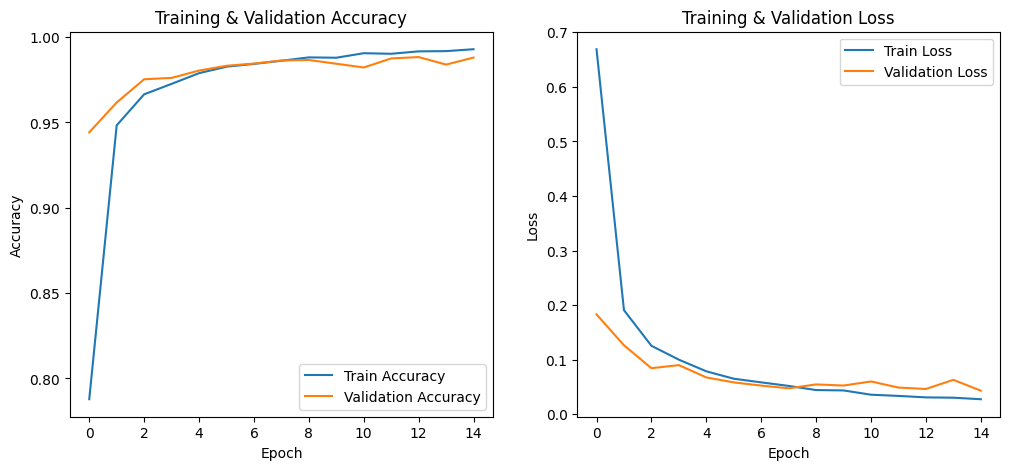

In [ ]:
# LSTM on MNIST (Optimized)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load MNIST Data

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training shape:", X_train.shape)  # (60000, 28, 28)


# 2. Build LSTM Model

model = models.Sequential([
    layers.LSTM(128, input_shape=(28, 28), return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


# 3. Train Model

history = model.fit(
    X_train, y_train_cat,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    verbose=1
)


# 4. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")


# 5. Predictions & Confusion Matrix

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM on MNIST')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))


# 6. Plot Accuracy & Loss

plt.figure(figsize=(12,5))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##AlexNet on CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,052,490 (30.72 MB)

 Trainable params: 8,049,738 (30.71 MB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.2732 - loss: 2.3538 - val_accuracy: 0.3181 - val_loss: 2.1661 - learning_rate: 0.0010
Epoch 2/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.4715 - loss: 1.4892 - val_accuracy: 0.5210 - val_loss: 1.2898 - learning_rate: 0.0010
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5733 - loss: 1.2302 - val_accuracy: 0.6037 - val_loss: 1.1316 - learning_rate: 0.0010
Epoch 4/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6296 - loss: 1.0881 - val_accuracy: 0.6931 - val_loss: 0.9201 - learning_rate: 0.0010
Epoch 5/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.6793 - loss: 0.9669 - val_accuracy: 0.6349 - val_loss: 1.0937 - learning_rate: 0.0010
Epoch 6/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7114 - loss: 0.8762 - val_accuracy: 0.7147 - val_loss: 0.9022 - learning_rate: 0.0010
Epoch 7/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.7387 - loss: 0.8053

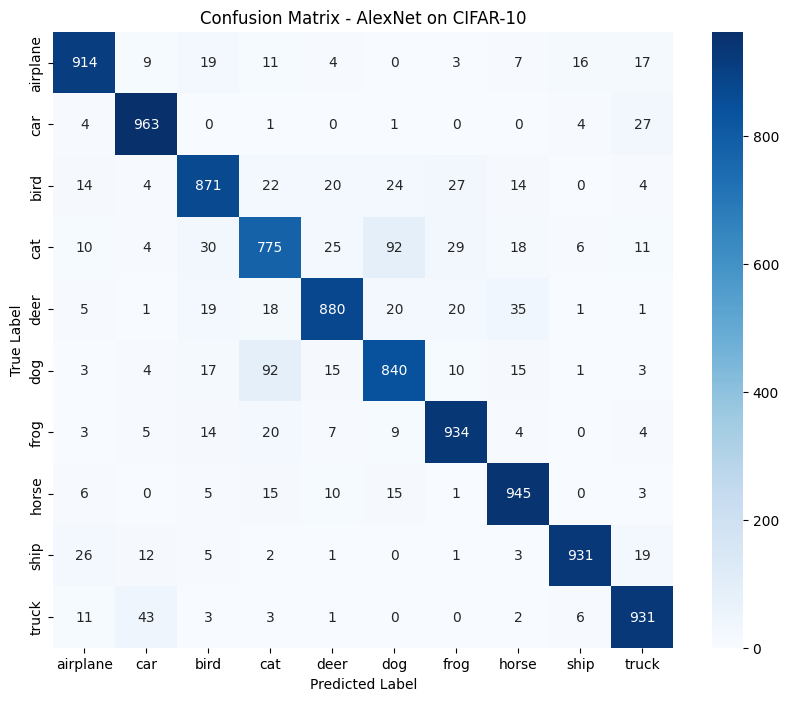


Classification Report:

              precision    recall  f1-score   support

    airplane       0.92      0.91      0.92      1000
         car       0.92      0.96      0.94      1000
        bird       0.89      0.87      0.88      1000
         cat       0.81      0.78      0.79      1000
        deer       0.91      0.88      0.90      1000
         dog       0.84      0.84      0.84      1000
        frog       0.91      0.93      0.92      1000
       horse       0.91      0.94      0.93      1000
        ship       0.96      0.93      0.95      1000
       truck       0.91      0.93      0.92      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



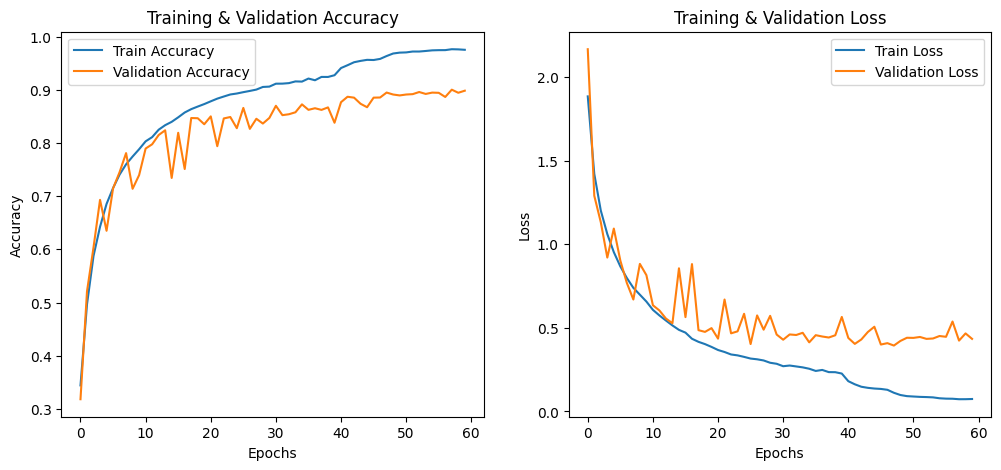

In [ ]:
# AlexNet on CIFAR-10 (Optimized for Accuracy & Speed)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load and Preprocess CIFAR-10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)


# 3. AlexNet Architecture (adapted for CIFAR-10)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(96, (3,3), strides=(1,1), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Conv Block 2
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Conv Block 3
    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Conv Block 4
    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Conv Block 5
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Flatten + Fully Connected Layers
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


# 4. Compile Model

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Learning Rate Scheduler
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=5, factor=0.5, min_lr=1e-5)


# 5. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=60,
    validation_data=(X_test, y_test_cat),
    callbacks=[lr_reduction],
    verbose=1
)


# 6. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")


# 7. Predictions, Confusion Matrix, Classification Report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AlexNet on CIFAR-10')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# 8. Training & Validation Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

##AlexNet on MNIST

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,052,490 (30.72 MB)

 Trainable params: 8,049,738 (30.71 MB)

 Non-trainable params: 2,752 (10.75 KB)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 55ms/step - accuracy: 0.7672 - loss: 0.9121 - val_accuracy: 0.9819 - val_loss: 0.0601 - learning_rate: 0.0010
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9673 - loss: 0.1259 - val_accuracy: 0.9731 - val_loss: 0.0989 - learning_rate: 0.0010
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9771 - loss: 0.0929 - val_accuracy: 0.9862 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9764 - loss: 0.0993 - val_accuracy: 0.9804 - val_loss: 0.0720 - learning_rate: 0.0010
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9805 - loss: 0.0829 - val_accuracy: 0.9857 - val_loss: 0.0566 - learning_rate: 0.0010
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9837 - loss: 0.0728 - val_accuracy: 0.9878 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - accuracy: 0.9841 - loss: 0.0737

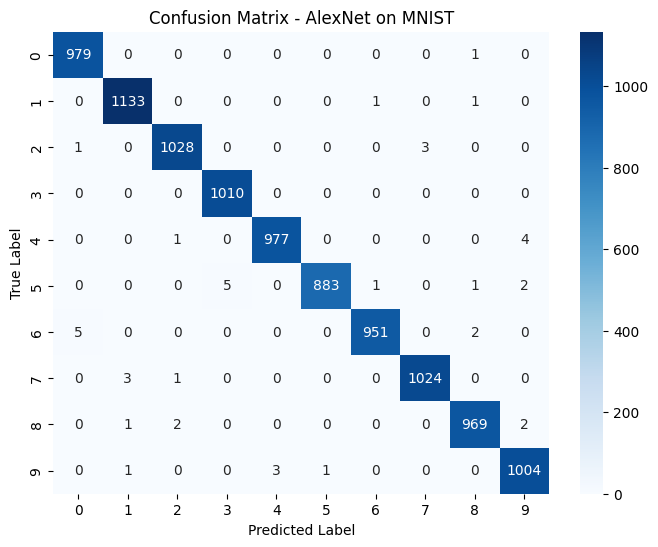


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       1.00      1.00      1.00      1028
           8       0.99      0.99      0.99       974
           9       0.99      1.00      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



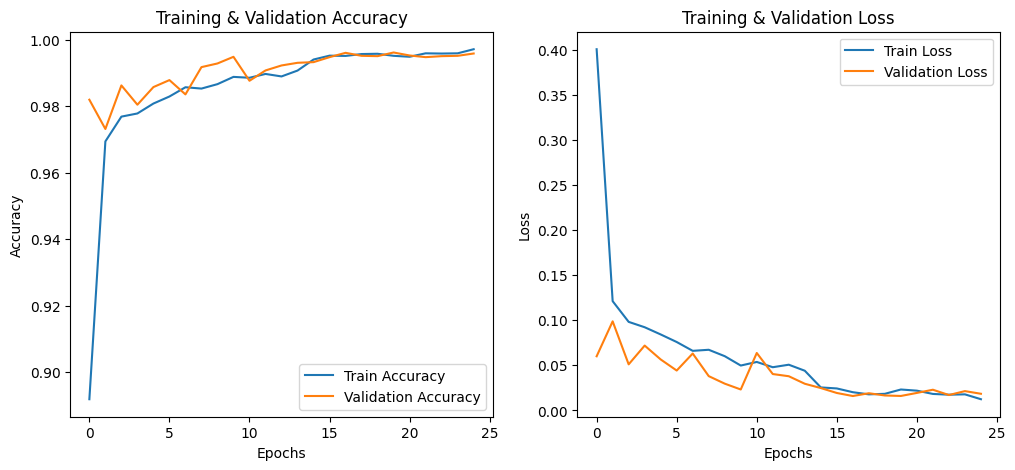

In [ ]:
# AlexNet on MNIST (Optimized for Speed & Accuracy)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load and Preprocess MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# MNIST shape: (28, 28) → AlexNet expects 3 channels (RGB-like)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Resize to 32x32 for AlexNet (original size 227x227 → we use smaller)
X_train = tf.image.resize(X_train, [32, 32])
X_test = tf.image.resize(X_test, [32, 32])

# Convert grayscale → 3-channel (for compatibility)
X_train = tf.image.grayscale_to_rgb(X_train)
X_test = tf.image.grayscale_to_rgb(X_test)

# Normalize pixel values
X_train = X_train.numpy().astype('float32') / 255.0
X_test = X_test.numpy().astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)


# 3. AlexNet Architecture (Adapted for MNIST)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(96, (3,3), strides=(1,1), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Conv Block 2
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Conv Block 3
    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Conv Block 4
    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Conv Block 5
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Flatten + Fully Connected Layers
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


# 4. Compile Model

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Learning Rate Scheduler
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=4, factor=0.5, min_lr=1e-5)


# 5. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=25,
    validation_data=(X_test, y_test_cat),
    callbacks=[lr_reduction],
    verbose=1
)


# 6. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")


# 7. Predictions, Confusion Matrix, Classification Report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - AlexNet on MNIST')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


# 8. Training & Validation Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


##GoogLeNet (Inception v1) on CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 96)  │     12,384 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 16)  │      2,064 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ max_pooling2d_1[… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │      8,256 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 128) │    110,720 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 32)  │     12,832 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 32)  │      4,128 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 256) │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_4[0][0],   │
│                     │                   │            │ conv2d_6[0][0],   │
│                     │                   │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 32)  │      8,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │     32,896 │ concatenate[0][0

 Total params: 5,922,490 (22.59 MB)

 Trainable params: 5,922,106 (22.59 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 88ms/step - accuracy: 0.2652 - loss: 1.8883 - val_accuracy: 0.4116 - val_loss: 1.6787 - learning_rate: 0.0010
Epoch 2/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.5187 - loss: 1.3292 - val_accuracy: 0.5488 - val_loss: 1.3074 - learning_rate: 0.0010
Epoch 3/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6075 - loss: 1.1058 - val_accuracy: 0.6022 - val_loss: 1.1421 - learning_rate: 0.0010
Epoch 4/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.6603 - loss: 0.9719 - val_accuracy: 0.6856 - val_loss: 0.8891 - learning_rate: 0.0010
Epoch 5/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6934 - loss: 0.8846 - val_accuracy: 0.7046 - val_loss: 0.8687 - learning_rate: 0.0010
Epoch 6/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.7174 - loss: 0.8075 - val_accuracy: 0.6501 - val_loss: 1.1055 - learning_rate: 0.0010
Epoch 7/60
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.7370 - loss: 0.766

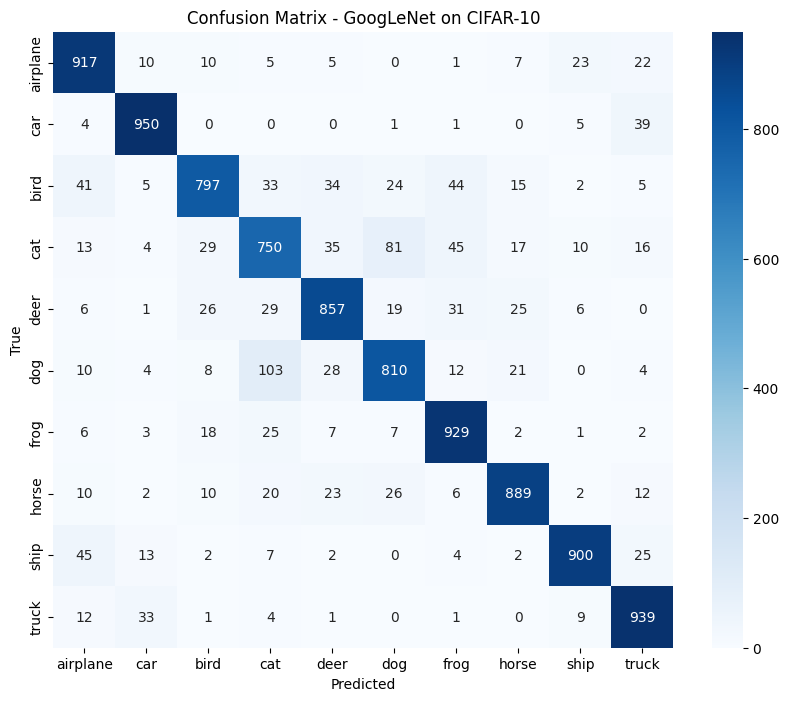


Classification Report:

              precision    recall  f1-score   support

    airplane       0.86      0.92      0.89      1000
         car       0.93      0.95      0.94      1000
        bird       0.88      0.80      0.84      1000
         cat       0.77      0.75      0.76      1000
        deer       0.86      0.86      0.86      1000
         dog       0.84      0.81      0.82      1000
        frog       0.86      0.93      0.90      1000
       horse       0.91      0.89      0.90      1000
        ship       0.94      0.90      0.92      1000
       truck       0.88      0.94      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



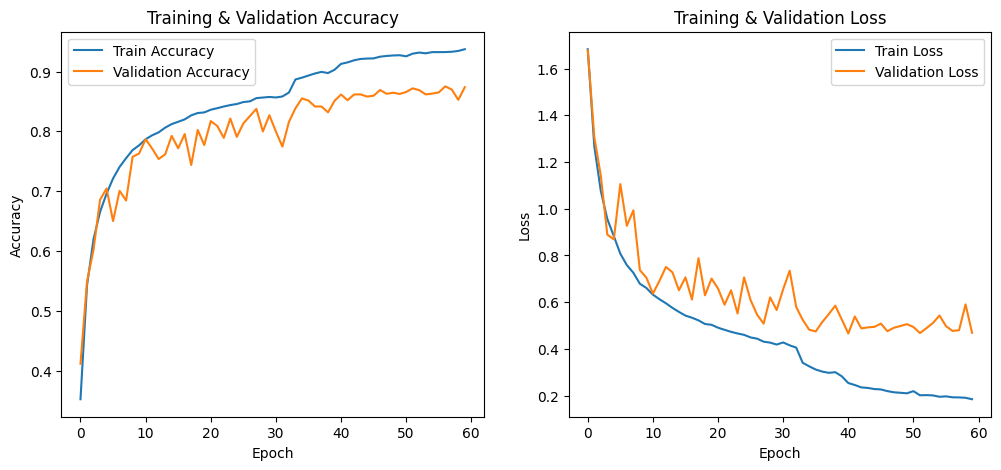

In [ ]:
# GoogLeNet (Inception v1) on CIFAR-10

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load and Preprocess CIFAR-10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)


# 3. Inception Module

def inception_module(x, filters):
    f1, f3r, f3, f5r, f5, fpp = filters

    path1 = layers.Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    path2 = layers.Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    path2 = layers.Conv2D(f3, (3,3), padding='same', activation='relu')(path2)

    path3 = layers.Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    path3 = layers.Conv2D(f5, (5,5), padding='same', activation='relu')(path3)

    path4 = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = layers.Conv2D(fpp, (1,1), padding='same', activation='relu')(path4)

    return layers.Concatenate(axis=-1)([path1, path2, path3, path4])


# 4. Build GoogLeNet (Simplified for CIFAR-10)

input_layer = Input(shape=(32,32,3))

# Stem
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

# Inception Blocks
x = inception_module(x, [64, 96, 128, 16, 32, 32])
x = inception_module(x, [128, 128, 192, 32, 96, 64])
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

x = inception_module(x, [192, 96, 208, 16, 48, 64])
x = inception_module(x, [160, 112, 224, 24, 64, 64])
x = inception_module(x, [128, 128, 256, 24, 64, 64])
x = inception_module(x, [112, 144, 288, 32, 64, 64])
x = inception_module(x, [256, 160, 320, 32, 128, 128])
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

x = inception_module(x, [256, 160, 320, 32, 128, 128])
x = inception_module(x, [384, 192, 384, 48, 128, 128])

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# Output Layer
output_layer = layers.Dense(10, activation='softmax')(x)

# Model
model = models.Model(inputs=input_layer, outputs=output_layer)
model.summary()


# 5. Compile Model

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Learning Rate Scheduler
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=5, factor=0.5, min_lr=1e-5)


# 6. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=60,
    validation_data=(X_test, y_test_cat),
    callbacks=[lr_reduction],
    verbose=1
)


# 7. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")


# 8. Predictions & Reports

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - GoogLeNet on CIFAR-10')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# 9. Plot Accuracy & Loss Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


##GoogLeNet (Inception v1) on MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 32, 32,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_56[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 8, 8, 96)  │     12,384 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 8, 8, 16)  │      2,064 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 8, 8, 128) │          0 │ max_pooling2d_14… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 8, 8, 64)  │      8,256 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 8, 8, 128) │    110,720 │ conv2d_59[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 8, 8, 32)  │     12,832 │ conv2d_61[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 8, 8, 32)  │      4,128 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 8, 8, 256) │          0 │ conv2d_58[0][0],  │
│ (Concatenate)       │                   │            │ conv2d_60[0][0],  │
│                     │                   │            │ conv2d_62[0][0],  │
│                     │                   │            │ conv2d_63[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 8, 8, 128) │     32,896 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 8, 8, 32)  │      8,224 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 8, 8, 256) │          0 │ concatenate_9[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 8, 8, 128) │     32,896 │ concatenate_9[0]

 Total params: 2,817,290 (10.75 MB)

 Trainable params: 2,816,906 (10.75 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 52ms/step - accuracy: 0.8088 - loss: 0.5511 - val_accuracy: 0.9685 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 2/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9778 - loss: 0.0783 - val_accuracy: 0.9901 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 3/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9854 - loss: 0.0550 - val_accuracy: 0.9773 - val_loss: 0.0877 - learning_rate: 0.0010
Epoch 4/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9862 - loss: 0.0525 - val_accuracy: 0.9874 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 5/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9873 - loss: 0.0468 - val_accuracy: 0.9897 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 6/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9927 - loss: 0.0271 - val_accuracy: 0.9943 - val_loss: 0.0173 - learning_rate: 5.0000e-04
Epoch 7/25
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9933 - loss: 0.

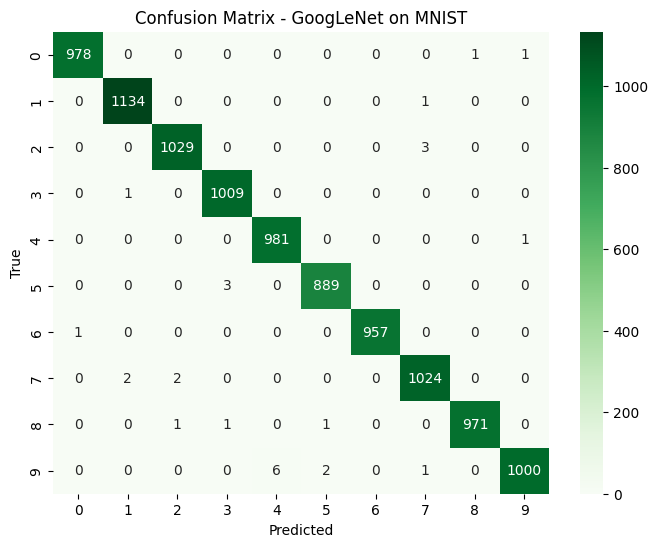


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      1.00      1.00       892
           6       1.00      1.00      1.00       958
           7       1.00      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



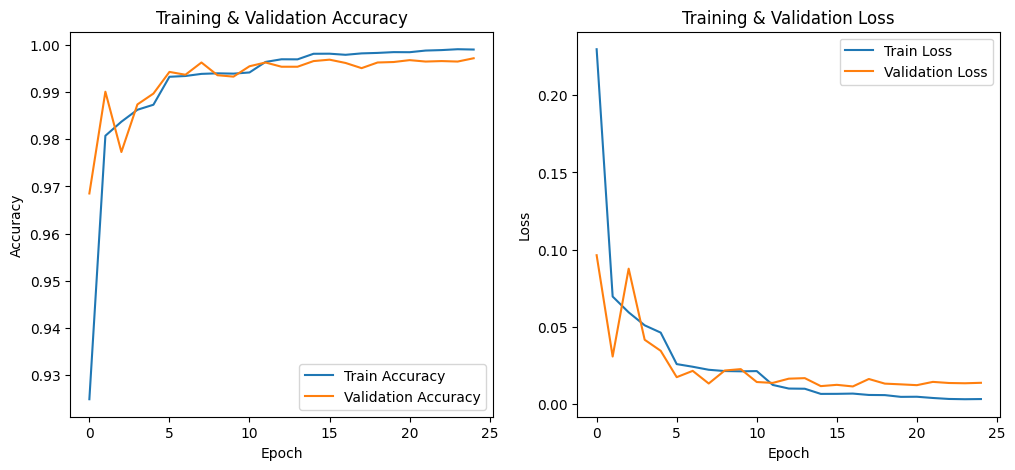

In [ ]:
# GoogLeNet (Inception v1) on MNIST

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Load and Preprocess MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Add channel dimension and resize to 32x32 to fit GoogLeNet input size
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_train = tf.image.resize(X_train, [32, 32])
X_test = tf.image.resize(X_test, [32, 32])

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# 2. Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)


# 3. Inception Module

def inception_module(x, filters):
    f1, f3r, f3, f5r, f5, fpp = filters

    path1 = layers.Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    path2 = layers.Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    path2 = layers.Conv2D(f3, (3,3), padding='same', activation='relu')(path2)

    path3 = layers.Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    path3 = layers.Conv2D(f5, (5,5), padding='same', activation='relu')(path3)

    path4 = layers.MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = layers.Conv2D(fpp, (1,1), padding='same', activation='relu')(path4)

    return layers.Concatenate(axis=-1)([path1, path2, path3, path4])


# 4. Build GoogLeNet (Simplified for MNIST)

input_layer = Input(shape=(32,32,1))

# Stem
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

# Inception Blocks
x = inception_module(x, [64, 96, 128, 16, 32, 32])
x = inception_module(x, [128, 128, 192, 32, 96, 64])
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

x = inception_module(x, [192, 96, 208, 16, 48, 64])
x = inception_module(x, [160, 112, 224, 24, 64, 64])
x = inception_module(x, [128, 128, 256, 24, 64, 64])
x = inception_module(x, [256, 160, 320, 32, 128, 128])
x = layers.MaxPooling2D((2,2), strides=(2,2))(x)

# Global Average Pooling
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# Output Layer
output_layer = layers.Dense(10, activation='softmax')(x)

# Model
model = models.Model(inputs=input_layer, outputs=output_layer)
model.summary()


# 5. Compile Model

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Learning Rate Scheduler
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-5)


# 6. Train Model

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=25,
    validation_data=(X_test, y_test_cat),
    callbacks=[lr_reduction],
    verbose=1
)


# 7. Evaluate Model

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")


# 8. Predictions & Reports

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - GoogLeNet on MNIST')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


# 9. Plot Accuracy & Loss Curves

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
